# Củ Chi Hourly Water-Level Forecast — Revised Baselines + Deployment

## Objective
Build a causal hourly forecasting pipeline for station **Củ Chi** and export a deployable LightGBM model package.

The notebook includes:
1. Chronological train/validation/test split
2. Persistence, Seasonal Naive (24 h), and expanding-window AutoReg(24) baselines
3. Causal lag and rolling features
4. Direct LightGBM models for 1 h, 3 h, and 6 h horizons
5. RMSE / MAE / R² comparison against all baselines
6. SHAP explainability and validation-based uncertainty bands
7. Production retraining on train + validation after test evaluation
8. Export of models, schema, metadata, inference helper, metrics, and ZIP bundle

### Target formulation
For horizon h:

`delta_h = water_level(t+h) - water_level(t)`

`predicted_level(t+h) = water_level(t) + predicted_delta_h`


## 0. Setup

In [49]:

import warnings
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
from statsmodels.tsa.ar_model import AutoReg

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("/home/workdir/artifacts")
OUT.mkdir(parents=True, exist_ok=True)

MODEL_DIR = OUT / "cuchi_hourly_revised"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = [1, 3, 6, 24]
RANDOM_STATE = 42
AR_LAGS = 24
SEASONAL_PERIOD_HOURS = 24


def find_file(name: str):
    candidates = [
        Path(name),
        Path("/home/workdir/attachments") / name,
        Path("/kaggle/working") / name,
        Path("/kaggle/input") / name,
    ]

    for p in candidates:
        if p.exists():
            return p

    for base in [
        Path("/home/workdir/attachments"),
        Path("/kaggle/input"),
        Path("/kaggle/working"),
    ]:
        if base.exists():
            hits = list(base.rglob(name))
            if hits:
                return hits[0]

    raise FileNotFoundError(f"Could not find {name}")


def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))


def mae(y, p):
    return float(mean_absolute_error(y, p))


def r2(y, p):
    return float(r2_score(y, p))


print("LightGBM:", lgb.__version__)
print("Output:", OUT)


LightGBM: 4.6.0
Output: /kaggle/working


## 1. Load and resample Củ Chi water level

The original data are recorded every 5 minutes. We aggregate to an hourly mean because the target is hourly forecasting.

For flood-event analysis, we also keep the hourly maximum as a diagnostic variable. It is **not** used as the main forecasting target.


In [50]:

wl_raw = pd.read_csv(find_file("Cu-Chi-post.csv"))
wl_raw.columns = ["datetime", "water_level"]

wl_raw["datetime"] = pd.to_datetime(wl_raw["datetime"])
wl_raw["water_level"] = pd.to_numeric(wl_raw["water_level"], errors="coerce")

wl_raw = (
    wl_raw
    .dropna(subset=["datetime", "water_level"])
    .sort_values("datetime")
    .drop_duplicates(subset=["datetime"])
)

wl = (
    wl_raw
    .set_index("datetime")
    .resample("1h")
    .agg(
        water_level=("water_level", "mean"),
        water_level_max=("water_level", "max"),
        water_level_min=("water_level", "min"),
    )
    .dropna(subset=["water_level"])
    .reset_index()
)

print("Raw 5-min rows :", len(wl_raw))
print("Hourly rows    :", len(wl))
print("Time range     :", wl["datetime"].min(), "→", wl["datetime"].max())
print()
print(wl.head())


Raw 5-min rows : 25440
Hourly rows    : 2122
Time range     : 2022-09-29 09:00:00 → 2022-12-26 18:00:00

             datetime  water_level  water_level_max  water_level_min
0 2022-09-29 09:00:00     0.661488         0.691154         0.630154
1 2022-09-29 10:00:00     0.454904         0.599154         0.329154
2 2022-09-29 11:00:00     0.194154         0.306154         0.084154
3 2022-09-29 12:00:00    -0.049012         0.067154        -0.165846
4 2022-09-29 13:00:00    -0.321762        -0.190846        -0.458846


## 2. Load tide and weather

Tide and weather are aligned to the hourly timestamp.

Because the original notebook had a small amount of missing tide data, missing tide values are filled by **time interpolation** rather than replacing them with zero. Rainfall missing values are treated as zero because the source variable represents precipitation.


In [51]:

# ----- Tide -----
tide = pd.read_csv(find_file("tide_hourly.csv"))
tide["datetime"] = pd.to_datetime(tide["datetime_nhabe"])

tide = (
    tide[
        ["datetime", "tide_vungtau_m"]
    ]
    .dropna(subset=["datetime"])
    .sort_values("datetime")
)

tide["datetime"] = tide["datetime"].dt.floor("h")
tide = tide.groupby("datetime", as_index=False).mean(numeric_only=True)

# ----- Weather -----
wx = pd.read_csv(find_file("cuchi-historical_weather_features.csv"))
wx["datetime"] = pd.to_datetime(wx["date"]).dt.tz_localize(None).dt.floor("h")

keep_wx = [
    "datetime",
    "Tram_Cu_Chi_precipitation",
    "Tram_Cu_Chi_wind_speed_10m",
    "Tram_Cu_Chi_wind_gusts_10m",
    "Tram_Cu_Chi_pressure_msl",
    "Dap_Tri_An_precipitation",
    "Dap_Dau_Tieng_precipitation",
]
keep_wx = [c for c in keep_wx if c in wx.columns]

wx = wx[keep_wx].groupby("datetime", as_index=False).mean(numeric_only=True)

# ----- Merge -----
df = (
    wl.merge(tide, on="datetime", how="left")
      .merge(wx, on="datetime", how="left")
      .sort_values("datetime")
      .reset_index(drop=True)
)

# Causal / practical missing-value treatment
for c in ["tide_nhabe_m", "tide_vungtau_m"]:
    if c in df.columns:
        df[c] = df[c].interpolate(method="linear", limit_direction="both")

for c in [
    "Tram_Cu_Chi_precipitation",
    "Dap_Tri_An_precipitation",
    "Dap_Dau_Tieng_precipitation",
]:
    if c in df.columns:
        df[c] = df[c].fillna(0)

print("Merged shape:", df.shape)
print("Missing values:")
print(df.isna().mean().sort_values(ascending=False).head(10))


Merged shape: (2122, 11)
Missing values:
datetime                      0.0
water_level                   0.0
water_level_max               0.0
water_level_min               0.0
tide_vungtau_m                0.0
Tram_Cu_Chi_precipitation     0.0
Tram_Cu_Chi_wind_speed_10m    0.0
Tram_Cu_Chi_wind_gusts_10m    0.0
Tram_Cu_Chi_pressure_msl      0.0
Dap_Tri_An_precipitation      0.0
dtype: float64


## 3. Feature engineering — causal time-series features

### Lag
For hourly data:
- `wl_lag1` = water level at t−1 hour
- `wl_lag3` = water level at t−3 hours
- `wl_lag24` = water level at t−24 hours

### Rolling
To make the information set explicit, the rolling features below use **only observations strictly before t**:

- 3-hour rolling mean = mean(t−3, t−2, t−1)
- 6-hour rolling mean = mean(t−6, …, t−1)
- 12-hour rolling mean = mean(t−12, …, t−1)

The model still receives `y_t` separately as the current observed water level, which is valid for a forecast made at time t.

This avoids ambiguity and reduces redundant overlap between `y_t` and rolling statistics.


In [52]:

def add_features(base: pd.DataFrame) -> pd.DataFrame:
    d = base.copy()

    # Current observed state
    d["y_t"] = d["water_level"]

    # Calendar / cyclic features
    d["hour"] = d["datetime"].dt.hour
    d["hour_sin"] = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d["hour"] / 24)
    d["dow"] = d["datetime"].dt.dayofweek
    d["dow_sin"] = np.sin(2 * np.pi * d["dow"] / 7)
    d["dow_cos"] = np.cos(2 * np.pi * d["dow"] / 7)

    # Water-level lags
    for lag in [1, 2, 3, 6, 12, 24]:
        d[f"wl_lag{lag}"] = d["water_level"].shift(lag)

    # Strictly causal rolling statistics: exclude y_t itself
    past_wl = d["water_level"].shift(1)
    for w in [3, 6, 12]:
        d[f"wl_roll_mean{w}"] = past_wl.rolling(w, min_periods=w).mean()
        d[f"wl_roll_max{w}"] = past_wl.rolling(w, min_periods=w).max()

    # Tide history / change
    if "tide_vungtau_m" in d.columns:
        for lag in [1, 2, 3, 6]:
            d[f"tide_vt_lag{lag}"] = d["tide_vungtau_m"].shift(lag)

        d["tide_vt_delta1"] = (
            d["tide_vungtau_m"] - d["tide_vungtau_m"].shift(1)
        )

    # Local rainfall
    rain_col = "Tram_Cu_Chi_precipitation"
    if rain_col in d.columns:
        d["rain"] = d[rain_col].fillna(0)

        for lag in [1, 2, 3]:
            d[f"rain_lag{lag}"] = d["rain"].shift(lag)

        d["rain_sum3"] = d["rain"].shift(1).rolling(3, min_periods=3).sum()
        d["rain_sum6"] = d["rain"].shift(1).rolling(6, min_periods=6).sum()

    # Upstream rainfall
    for col in [
        "Dap_Tri_An_precipitation",
        "Dap_Dau_Tieng_precipitation",
    ]:
        if col in d.columns:
            d[col] = d[col].fillna(0)
            d[f"{col}_sum3"] = d[col].shift(1).rolling(3, min_periods=3).sum()

    return d


df = add_features(df)

# Future targets
for h in HORIZONS:
    df[f"target_h{h}"] = df["water_level"].shift(-h)
    df[f"delta_h{h}"] = df[f"target_h{h}"] - df["water_level"]

print("Feature-enriched shape:", df.shape)
print(df[[
    "datetime",
    "water_level",
    "y_t",
    "wl_lag1",
    "wl_roll_mean3",
    "target_h1",
    "delta_h1",
]].head(10))


Feature-enriched shape: (2122, 51)
             datetime  water_level       y_t   wl_lag1  wl_roll_mean3  \
0 2022-09-29 09:00:00     0.661488  0.661488       NaN            NaN   
1 2022-09-29 10:00:00     0.454904  0.454904  0.661488            NaN   
2 2022-09-29 11:00:00     0.194154  0.194154  0.454904            NaN   
3 2022-09-29 12:00:00    -0.049012 -0.049012  0.194154       0.436849   
4 2022-09-29 13:00:00    -0.321762 -0.321762 -0.049012       0.200015   
5 2022-09-29 14:00:00    -0.615512 -0.615512 -0.321762      -0.058873   
6 2022-09-29 15:00:00    -0.781262 -0.781262 -0.615512      -0.328762   
7 2022-09-29 16:00:00    -0.329346 -0.329346 -0.781262      -0.572846   
8 2022-09-29 17:00:00     0.110238  0.110238 -0.329346      -0.575373   
9 2022-09-29 18:00:00     0.425571  0.425571  0.110238      -0.333457   

   target_h1  delta_h1  
0   0.454904 -0.206583  
1   0.194154 -0.260750  
2  -0.049012 -0.243167  
3  -0.321762 -0.272750  
4  -0.615512 -0.293750  
5  -0.78126

## 4. Add static station features

The file `stations_master_features.csv` contains station-level static attributes:

- longitude / latitude
- distance to river
- tide-influence indicators
- impervious-surface percentage
- channel length
- channel density

In [53]:

# Load station-level static metadata
stations = pd.read_csv(find_file("stations_master_features.csv"))

print("Available stations:")
print(stations["tenTram"].tolist())

# Select the Củ Chi row robustly (Unicode-normalized station name).
import unicodedata

def normalize_station_name(x):
    return unicodedata.normalize("NFC", str(x).strip().lower())

stations["tenTram_norm"] = stations["tenTram"].apply(normalize_station_name)
cuchi_matches = stations[
    stations["tenTram_norm"].str.contains("củ chi", regex=False, na=False)
].copy()

if cuchi_matches.empty:
    raise ValueError("Could not find a Củ Chi row in stations_master_features.csv")

cuchi_static = cuchi_matches.iloc[0]

STATIC_COL_MAP = {
    "lon": "station_lon",
    "lat": "station_lat",
    "dist_to_river_m": "station_dist_to_river_m",
    "tide_inf_sigmoid": "station_tide_inf_sigmoid",
    "tide_inf_exp": "station_tide_inf_exp",
    "pct_impervious": "station_pct_impervious",
    "channel_length_m": "station_channel_length_m",
    "channel_density_m_m2": "station_channel_density_m_m2",
}

for src_col, dst_col in STATIC_COL_MAP.items():
    if src_col not in stations.columns:
        raise KeyError(f"Missing static column: {src_col}")

    df[dst_col] = float(cuchi_static[src_col])

STATIC_FEATURES = list(STATIC_COL_MAP.values())

print("\nCu Chi static features:")
print(
    pd.Series(
        {dst: cuchi_static[src] for src, dst in STATIC_COL_MAP.items()},
        name="value",
    ).to_string()
)

print("\nStatic-feature variance in the single-station Củ Chi table:")
static_variance = df[STATIC_FEATURES].var()
print(static_variance.to_string())

assert np.isclose(static_variance.fillna(0).to_numpy(), 0).all()
print("\nAll static features are constant across time for this single-station setup: PASSED")


Available stations:
['An Phú', 'Cát Lái', 'Cần Giờ', 'Củ Chi', 'Hóc Môn', 'Lê Minh Xuân', 'Phạm Văn Cội', 'Thủ Đức', 'Nhà Bè', 'Phú An']

Cu Chi static features:
station_lon                      106.512778
station_lat                       10.955556
station_dist_to_river_m          841.645767
station_tide_inf_sigmoid           0.031800
station_tide_inf_exp               0.185800
station_pct_impervious             0.521200
station_channel_length_m        1033.880000
station_channel_density_m_m2       0.000329

Static-feature variance in the single-station Củ Chi table:
station_lon                     5.302432e-24
station_lat                     2.318482e-25
station_dist_to_river_m         1.391146e-21
station_tide_inf_sigmoid        1.187366e-30
station_tide_inf_exp            9.173676e-29
station_pct_impervious          5.051090e-29
station_channel_length_m        3.181181e-21
station_channel_density_m_m2    2.033653e-34

All static features are constant across time for this single-sta

## 4. Leakage sanity check

A feature is considered safe if, at timestamp t, it does not use the unknown future value t+1, t+2, …

The explicit design below guarantees:

- lags use past timestamps;
- rolling water-level features are shifted by 1 before rolling;
- future targets are stored separately;
- the chronological test period is never used to fit the model.


In [54]:

# Check that feature construction does not literally reference future timestamps.
future_like = [
    c for c in df.columns
    if c.startswith("target_") or c.startswith("delta_")
]

print("Future target columns kept OUT of X:", future_like)

# Quick audit: rolling feature at row i must be computable from earlier rows.
i = 20
expected_mean3 = df.loc[i-3:i-1, "water_level"].mean()
actual_mean3 = df.loc[i, "wl_roll_mean3"]

print(f"Example row {i}:")
print("Expected causal roll_mean3:", expected_mean3)
print("Stored roll_mean3         :", actual_mean3)

assert np.isclose(expected_mean3, actual_mean3, equal_nan=True)
print("Causal rolling check: PASSED")


Future target columns kept OUT of X: ['target_h1', 'delta_h1', 'target_h3', 'delta_h3', 'target_h6', 'delta_h6', 'target_h24', 'delta_h24']
Example row 20:
Expected causal roll_mean3: -0.18015121549595522
Stored roll_mean3         : -0.18015121549595522
Causal rolling check: PASSED


## 5. Feature list and chronological split

Static station metadata are also included in `FEAT`. In the current single-station setup they are constant, so they are expected to have no meaningful predictive contribution.

We use:

- 70% train
- 15% validation
- 15% test

The split is chronological; there is no random shuffling.


In [55]:

ban = (
    {"datetime", "water_level", "water_level_max", "water_level_min"}
    | {f"target_h{h}" for h in HORIZONS}
    | {f"delta_h{h}" for h in HORIZONS}
)

FEAT = [
    c for c in df.columns
    if c not in ban and df[c].dtype != "O"
]

print("Feature count:", len(FEAT))
print(FEAT)

split_base = df.dropna(subset=["delta_h1"]).copy()

n = len(split_base)
i_train = int(n * 0.70)
i_val = int(n * 0.85)

print()
print("Approx split sizes:")
print("train:", i_train)
print("val  :", i_val - i_train)
print("test :", n - i_val)


Feature count: 47
['tide_vungtau_m', 'Tram_Cu_Chi_precipitation', 'Tram_Cu_Chi_wind_speed_10m', 'Tram_Cu_Chi_wind_gusts_10m', 'Tram_Cu_Chi_pressure_msl', 'Dap_Tri_An_precipitation', 'Dap_Dau_Tieng_precipitation', 'y_t', 'hour', 'hour_sin', 'hour_cos', 'dow', 'dow_sin', 'dow_cos', 'wl_lag1', 'wl_lag2', 'wl_lag3', 'wl_lag6', 'wl_lag12', 'wl_lag24', 'wl_roll_mean3', 'wl_roll_max3', 'wl_roll_mean6', 'wl_roll_max6', 'wl_roll_mean12', 'wl_roll_max12', 'tide_vt_lag1', 'tide_vt_lag2', 'tide_vt_lag3', 'tide_vt_lag6', 'tide_vt_delta1', 'rain', 'rain_lag1', 'rain_lag2', 'rain_lag3', 'rain_sum3', 'rain_sum6', 'Dap_Tri_An_precipitation_sum3', 'Dap_Dau_Tieng_precipitation_sum3', 'station_lon', 'station_lat', 'station_dist_to_river_m', 'station_tide_inf_sigmoid', 'station_tide_inf_exp', 'station_pct_impervious', 'station_channel_length_m', 'station_channel_density_m_m2']

Approx split sizes:
train: 1484
val  : 318
test : 319


## 6. Baseline models

We evaluate three increasingly informative time-series baselines before the proposed LightGBM model:

1. **Persistence** — assumes the future water level remains equal to the current level. This is the minimum benchmark for a slowly varying series.
2. **Seasonal Naive (24 h)** — predicts the future value from the same seasonal position on the previous day: `ŷ(t+h) = y(t+h-24)`. This tests whether daily periodicity alone is sufficient.
3. **Expanding-window AutoReg(24)** — a univariate autoregressive baseline using the previous 24 hourly water levels. At each test forecast origin, the model is fitted only on observations available up to that origin, then forecasts h steps ahead. This tests whether water-level history alone can explain the forecast.

The baselines do not use future test observations. Persistence and Seasonal Naive are deterministic; AutoReg uses only the water-level series.


In [56]:
# ------------------------------------------------------------
# Baseline 1: Persistence
# Baseline 2: Seasonal Naive (24 h)
# Baseline 3: Expanding-window AutoReg(24)
# ------------------------------------------------------------

def evaluate_persistence(df, horizon):
    data = df.dropna(subset=[f"target_h{horizon}"]).copy().reset_index(drop=True)
    n = len(data)
    i_test = int(n * 0.85)
    te = data.iloc[i_test:]
    return te[f"target_h{horizon}"].to_numpy(), te["y_t"].to_numpy()


def evaluate_seasonal_naive(df, horizon, seasonal_period=24):
    data = df.dropna(subset=[f"target_h{horizon}"]).copy().reset_index(drop=True)
    n = len(data)
    i_test = int(n * 0.85)
    te = data.iloc[i_test:].copy()
    source_shift = seasonal_period - horizon
    te["pred"] = data["y_t"].shift(source_shift).iloc[i_test:].to_numpy()
    valid = te[[f"target_h{horizon}", "pred"]].dropna()
    return valid[f"target_h{horizon}"].to_numpy(), valid["pred"].to_numpy()


def evaluate_autoreg_expanding(df, horizon, lags=24):
    """Expanding-window AutoReg using only observations available at each origin."""
    data = df.dropna(subset=[f"target_h{horizon}", "water_level"]).copy().reset_index(drop=True)
    n = len(data)
    i_test = int(n * 0.85)
    preds, actuals, origins = [], [], []

    for pos in range(i_test, n):
        history = data.iloc[:pos + 1]["water_level"].astype(float).reset_index(drop=True)
        try:
            ar = AutoReg(history, lags=lags, trend="c", old_names=False).fit()
            fc = ar.predict(start=len(history), end=len(history) + horizon - 1, dynamic=False)
            pred_h = float(np.asarray(fc)[-1])
        except Exception:
            # Numerical fallback at one origin; still uses no future values.
            pred_h = float(history.iloc[-1])

        preds.append(pred_h)
        actuals.append(float(data.loc[pos, f"target_h{horizon}"]))
        origins.append(data.loc[pos, "datetime"])

    return pd.DataFrame({"datetime": origins, "y_true": actuals, "y_pred": preds})


baseline_rows = []
baseline_predictions = {}

for h in HORIZONS:
    y_true, y_pred = evaluate_persistence(df, h)
    baseline_rows.append({"horizon_h": h, "model": "Persistence", "RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred), "R2": r2(y_true, y_pred)})
    baseline_predictions[("Persistence", h)] = (y_true, y_pred)

    y_true, y_pred = evaluate_seasonal_naive(df, h, seasonal_period=SEASONAL_PERIOD_HOURS)
    baseline_rows.append({"horizon_h": h, "model": "SeasonalNaive24", "RMSE": rmse(y_true, y_pred), "MAE": mae(y_true, y_pred), "R2": r2(y_true, y_pred)})
    baseline_predictions[("SeasonalNaive24", h)] = (y_true, y_pred)

    ar_eval = evaluate_autoreg_expanding(df, h, lags=AR_LAGS)
    baseline_rows.append({"horizon_h": h, "model": f"AutoReg{AR_LAGS}", "RMSE": rmse(ar_eval["y_true"], ar_eval["y_pred"]), "MAE": mae(ar_eval["y_true"], ar_eval["y_pred"]), "R2": r2(ar_eval["y_true"], ar_eval["y_pred"])})
    baseline_predictions[(f"AutoReg{AR_LAGS}", h)] = ar_eval

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(OUT / "cuchi_baseline_metrics.csv", index=False)
print("=== BASELINE RESULTS ===")
print(baseline_df.to_string(index=False))


=== BASELINE RESULTS ===
 horizon_h           model     RMSE      MAE        R2
         1     Persistence 0.207709 0.175369  0.848315
         1 SeasonalNaive24 0.219914 0.165532  0.829964
         1       AutoReg24 0.064950 0.044344  0.985168
         3     Persistence 0.550541 0.468557 -0.062520
         3 SeasonalNaive24 0.220194 0.165750  0.830032
         3       AutoReg24 0.148931 0.103237  0.922245
         6     Persistence 0.844397 0.685773 -1.499483
         6 SeasonalNaive24 0.220194 0.165750  0.830032
         6       AutoReg24 0.171282 0.113582  0.897156
        24     Persistence 0.220979 0.166292  0.827096
        24 SeasonalNaive24 0.220979 0.166292  0.827096
        24       AutoReg24 0.162982 0.105990  0.905946


## 7. Train LightGBM for each forecast horizon

The model predicts **Δ water level**, then reconstructs the future level:

`predicted_level = current_level + predicted_delta`

Early stopping uses the chronological validation set.


In [57]:

models = {}
metrics = []
preds_test = {}
validation_intervals = {}

for h in HORIZONS:
    print("\n" + "=" * 60)
    print(f"Horizon t+{h}h")

    data = df.dropna(subset=[f"delta_h{h}", f"target_h{h}"]).copy()
    data = data.reset_index(drop=True)

    n = len(data)
    i_tr = int(n * 0.70)
    i_va = int(n * 0.85)

    tr = data.iloc[:i_tr]
    va = data.iloc[i_tr:i_va]
    te = data.iloc[i_va:]

    Xtr = tr[FEAT].copy()
    Xva = va[FEAT].copy()
    Xte = te[FEAT].copy()

    # Remaining feature NaNs are filled only from known/current information.
    Xtr = Xtr.replace([np.inf, -np.inf], np.nan).fillna(0)
    Xva = Xva.replace([np.inf, -np.inf], np.nan).fillna(0)
    Xte = Xte.replace([np.inf, -np.inf], np.nan).fillna(0)

    ytr = tr[f"delta_h{h}"]
    yva = va[f"delta_h{h}"]
    yte = te[f"delta_h{h}"]

    model = lgb.LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=24,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

    model.fit(
        Xtr,
        ytr,
        eval_set=[(Xva, yva)],
        callbacks=[lgb.early_stopping(30, verbose=False)],
    )

    # Validation predictions for interval calibration
    pred_delta_va = model.predict(Xva)
    pred_level_va = va["y_t"].to_numpy() + pred_delta_va
    abs_resid_va = np.abs(
        va[f"target_h{h}"].to_numpy() - pred_level_va
    )

    q90 = float(np.quantile(abs_resid_va, 0.90))

    # Final test predictions
    pred_delta = model.predict(Xte)
    pred_level = te["y_t"].to_numpy() + pred_delta

    y_true = te[f"target_h{h}"].to_numpy()

    met = {
        "horizon_h": h,
        "model": "LightGBM",
        "RMSE": rmse(y_true, pred_level),
        "MAE": mae(y_true, pred_level),
        "R2": r2(y_true, pred_level),
        "validation_q90_error": q90,
        "n_train": len(tr),
        "n_val": len(va),
        "n_test": len(te),
    }

    metrics.append(met)
    models[h] = model
    validation_intervals[h] = q90

    te_out = te[
        ["datetime", "y_t", f"target_h{h}"]
    ].copy()

    te_out["pred_delta"] = pred_delta
    te_out["pred_level"] = pred_level
    te_out["pred_lo"] = pred_level - q90
    te_out["pred_hi"] = pred_level + q90

    preds_test[h] = te_out
    te_out.to_csv(
        OUT / f"cuchi_pred_h{h}h_test.csv",
        index=False,
    )

    print(pd.Series(met).to_string())

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUT / "cuchi_metrics_hourly.csv", index=False)

print("\n=== LIGHTGBM SUMMARY ===")
print(metrics_df.to_string(index=False))



Horizon t+1h
horizon_h                      1
model                   LightGBM
RMSE                    0.066351
MAE                     0.045115
R2                      0.984522
validation_q90_error    0.068049
n_train                     1484
n_val                        318
n_test                       319

Horizon t+3h
horizon_h                      3
model                   LightGBM
RMSE                    0.140601
MAE                     0.104731
R2                        0.9307
validation_q90_error    0.136734
n_train                     1483
n_val                        318
n_test                       318

Horizon t+6h
horizon_h                      6
model                   LightGBM
RMSE                    0.190803
MAE                     0.141024
R2                      0.872378
validation_q90_error    0.221005
n_train                     1481
n_val                        317
n_test                       318

Horizon t+24h
horizon_h                     24
model              

## 8. Compare all baselines against LightGBM

Persistence is retained as the minimum benchmark, but the more informative comparisons are Seasonal Naive and AutoReg(24). The key question is whether LightGBM adds value beyond models that already exploit the temporal structure of Củ Chi water level.


In [58]:
comparison = pd.concat([
    baseline_df[["horizon_h", "model", "RMSE", "MAE", "R2"]],
    metrics_df[["horizon_h", "model", "RMSE", "MAE", "R2"]],
], ignore_index=True)
comparison = comparison.sort_values(["horizon_h", "MAE"]).reset_index(drop=True)
comparison.to_csv(OUT / "cuchi_model_comparison.csv", index=False)

rows = []
for h in HORIZONS:
    m = metrics_df.loc[metrics_df["horizon_h"] == h].iloc[0]
    for _, b in baseline_df[baseline_df["horizon_h"] == h].iterrows():
        rows.append({
            "horizon_h": h,
            "baseline": b["model"],
            "MAE_baseline": b["MAE"],
            "MAE_lightgbm": m["MAE"],
            "MAE_improvement_pct": 100 * (b["MAE"] - m["MAE"]) / b["MAE"],
            "RMSE_baseline": b["RMSE"],
            "RMSE_lightgbm": m["RMSE"],
            "RMSE_improvement_pct": 100 * (b["RMSE"] - m["RMSE"]) / b["RMSE"],
        })
improvement_df = pd.DataFrame(rows)
improvement_df.to_csv(OUT / "cuchi_baseline_improvement.csv", index=False)

print("=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))
print("\n=== LIGHTGBM IMPROVEMENT OVER EACH BASELINE ===")
print(improvement_df.to_string(index=False))


=== MODEL COMPARISON ===
 horizon_h           model     RMSE      MAE        R2
         1       AutoReg24 0.064950 0.044344  0.985168
         1        LightGBM 0.066351 0.045115  0.984522
         1 SeasonalNaive24 0.219914 0.165532  0.829964
         1     Persistence 0.207709 0.175369  0.848315
         3       AutoReg24 0.148931 0.103237  0.922245
         3        LightGBM 0.140601 0.104731  0.930700
         3 SeasonalNaive24 0.220194 0.165750  0.830032
         3     Persistence 0.550541 0.468557 -0.062520
         6       AutoReg24 0.171282 0.113582  0.897156
         6        LightGBM 0.190803 0.141024  0.872378
         6 SeasonalNaive24 0.220194 0.165750  0.830032
         6     Persistence 0.844397 0.685773 -1.499483
        24       AutoReg24 0.162982 0.105990  0.905946
        24        LightGBM 0.155592 0.106328  0.914281
        24     Persistence 0.220979 0.166292  0.827096
        24 SeasonalNaive24 0.220979 0.166292  0.827096

=== LIGHTGBM IMPROVEMENT OVER EACH BASE

## 9. Production model retraining

The test-set models are used only for honest evaluation. After evaluation, deployable LightGBM models are retrained on **train + validation data (85%)** using the best number of boosting iterations selected during validation.

The untouched test set is never used for fitting the production models.


In [59]:
production_models = {}
production_n_estimators = {}

for h in HORIZONS:
    data = df.dropna(subset=[f"delta_h{h}", f"target_h{h}"]).copy().reset_index(drop=True)
    i_fit = int(len(data) * 0.85)
    train_val = data.iloc[:i_fit]

    X_fit = train_val[FEAT].replace([np.inf, -np.inf], np.nan).fillna(0)
    y_fit = train_val[f"delta_h{h}"]

    eval_model = models[h]
    best_iter = int(getattr(eval_model, "best_iteration_", 0) or 0)
    if best_iter <= 0:
        best_iter = int(eval_model.get_params().get("n_estimators", 400))

    model = lgb.LGBMRegressor(
        n_estimators=best_iter, learning_rate=0.05, max_depth=5, num_leaves=24,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )
    model.fit(X_fit, y_fit)
    production_models[h] = model
    production_n_estimators[h] = best_iter

print("Production n_estimators:", production_n_estimators)


Production n_estimators: {1: 226, 3: 101, 6: 226, 24: 46}


## 10. SHAP explainability

SHAP (SHapley Additive exPlanations) explains individual LightGBM predictions by decomposing the prediction into feature contributions.

For this notebook we use SHAP for the **t+1h model** first because it is the most accurate horizon and is the most useful for short-term operational interpretation.

Two levels of explanation are produced:

1. **Global explanation** — which features are generally most influential across the test set.
2. **Local explanation** — for one specific prediction, which features pushed the forecast higher or lower.

> SHAP describes the model's learned behavior. It does **not** prove physical causality.


### Static-feature SHAP interpretation

Because the static station features are constant in a single-station dataset, their SHAP values should be approximately zero / non-informative. If a static feature appears highly important here, investigate the data pipeline before interpreting it.


In [60]:

# Install/import SHAP
try:
    import shap
except ImportError as e:
    raise ImportError(
        "SHAP is not installed in this environment. "
        "Install it with: pip install shap"
    ) from e

print("SHAP version:", shap.__version__)


SHAP version: 0.51.0


In [61]:

# ------------------------------------------------------------
# Prepare the t+1h test matrix
# ------------------------------------------------------------
h = 1

data_h1 = df.dropna(
    subset=[f"delta_h{h}", f"target_h{h}"]
).copy().reset_index(drop=True)

n = len(data_h1)
i_tr = int(n * 0.70)
i_va = int(n * 0.85)

te_h1 = data_h1.iloc[i_va:].copy()

X_test_h1 = (
    te_h1[FEAT]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

model_h1 = models[1]

# TreeExplainer is exact/efficient for tree-based LightGBM models.
explainer_h1 = shap.TreeExplainer(model_h1)
shap_values_h1 = explainer_h1.shap_values(X_test_h1)

# Ensure a 2D matrix for regression
if isinstance(shap_values_h1, list):
    shap_values_h1 = shap_values_h1[0]

print("SHAP matrix shape:", np.asarray(shap_values_h1).shape)
print("Test feature matrix shape:", X_test_h1.shape)


SHAP matrix shape: (319, 47)
Test feature matrix shape: (319, 47)


### 10.1 Global SHAP importance

The bar plot below ranks features by mean absolute SHAP value:

`mean(|SHAP value|)`

A larger value means the feature has a larger average influence on the model prediction.

Unlike raw LightGBM split importance, SHAP importance is directly tied to the **magnitude of contribution to predictions**.


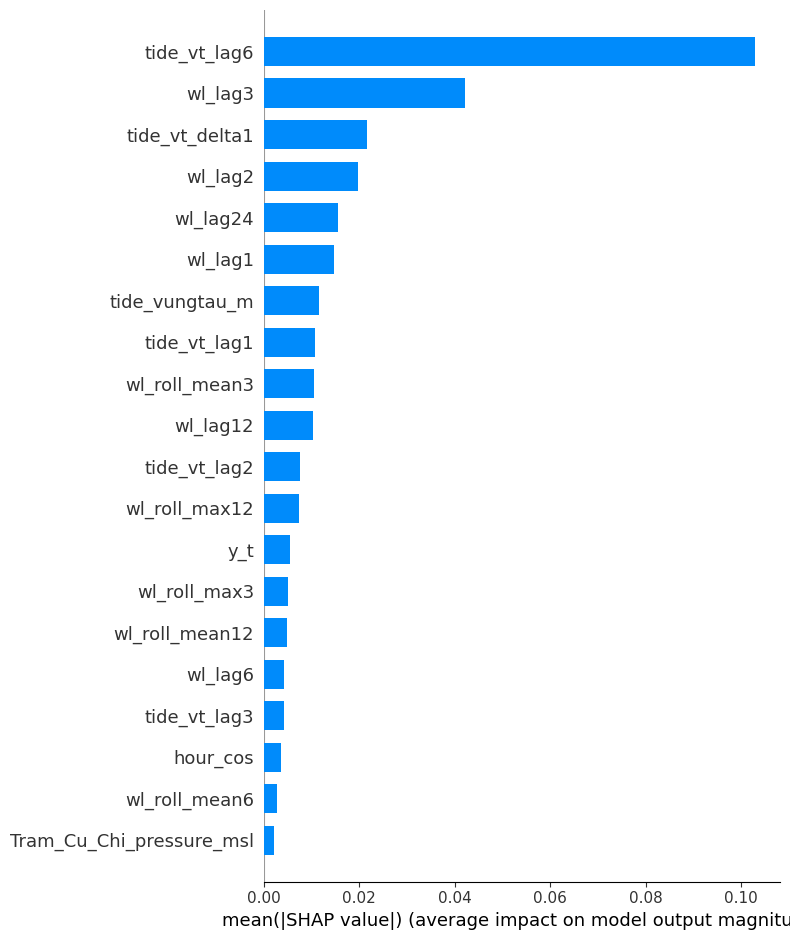

In [62]:

# Global SHAP bar plot
shap.summary_plot(
    shap_values_h1,
    X_test_h1,
    plot_type="bar",
    max_display=20,
    show=True,
)


### 10.2 SHAP beeswarm: direction of influence

The beeswarm plot adds direction:

- **Positive SHAP** → pushes the predicted Δ water level upward.
- **Negative SHAP** → pushes the predicted Δ water level downward.
- Color indicates the feature value (low → high).

Because the model predicts **Δ water level**, the SHAP direction refers to the predicted change first; the final future level is reconstructed as:

`predicted level = current level + predicted Δ`.


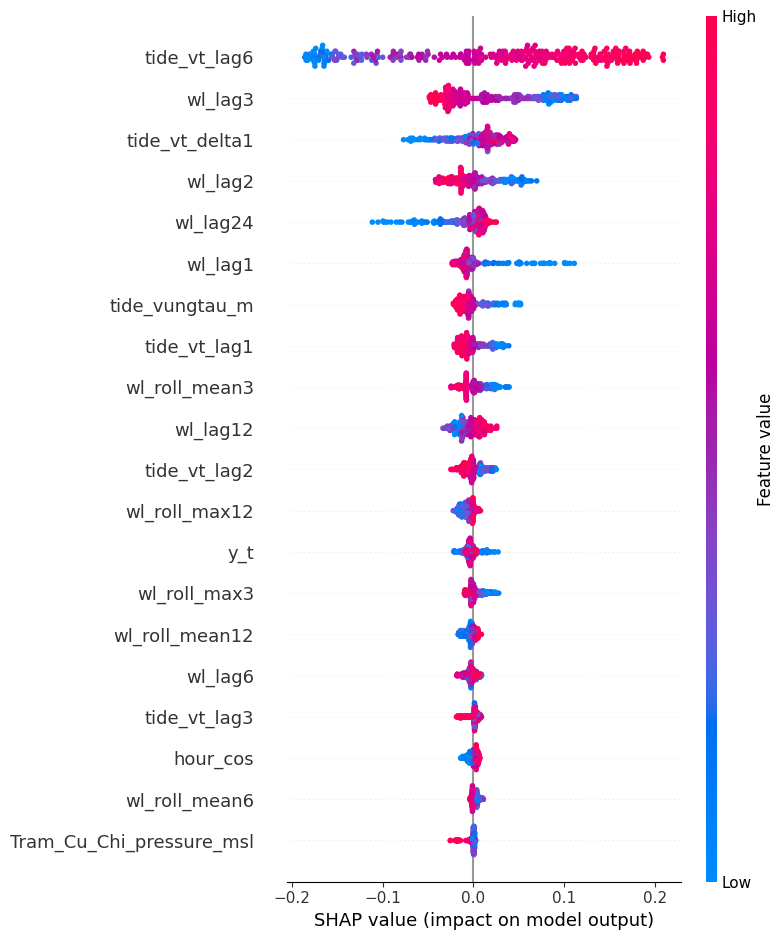

In [63]:

shap.summary_plot(
    shap_values_h1,
    X_test_h1,
    max_display=20,
    show=True,
)


### 10.3 SHAP values as a table

This table makes the explanation easier to inspect programmatically.

`shap_value > 0` means that feature pushes the model toward a **larger future water-level increase** relative to the model's expected value.

`shap_value < 0` means that feature pushes the model toward a **smaller increase / larger decrease**.


In [64]:

# Mean absolute SHAP importance
mean_abs_shap = pd.Series(
    np.abs(shap_values_h1).mean(axis=0),
    index=FEAT,
    name="mean_abs_shap",
).sort_values(ascending=False)

print("Top 20 features by mean |SHAP|:")
print(mean_abs_shap.head(20).to_string())

mean_abs_shap.head(20).to_csv(
    OUT / "cuchi_shap_global_h1.csv"
)


Top 20 features by mean |SHAP|:
tide_vt_lag6                0.102962
wl_lag3                     0.042054
tide_vt_delta1              0.021536
wl_lag2                     0.019651
wl_lag24                    0.015577
wl_lag1                     0.014683
tide_vungtau_m              0.011601
tide_vt_lag1                0.010752
wl_roll_mean3               0.010606
wl_lag12                    0.010277
tide_vt_lag2                0.007517
wl_roll_max12               0.007304
y_t                         0.005451
wl_roll_max3                0.005132
wl_roll_mean12              0.004877
wl_lag6                     0.004294
tide_vt_lag3                0.004205
hour_cos                    0.003683
wl_roll_mean6               0.002776
Tram_Cu_Chi_pressure_msl    0.002205


### 10.4 Local explanation for one test prediction

The following selects the test example with the **largest absolute forecasting error**.

This is useful because it shows where the model went wrong rather than only explaining an easy prediction.


In [65]:

# Select the worst absolute-error example on the t+1h test set
pred_h1 = preds_test[1].copy()
pred_h1["abs_error"] = np.abs(
    pred_h1["target_h1"] - pred_h1["pred_level"]
)

worst_idx = int(pred_h1["abs_error"].idxmax())

# idxmax above is the DataFrame index; map it to positional index safely.
worst_pos = pred_h1.index.get_loc(worst_idx)

x_worst = X_test_h1.iloc[[worst_pos]]

print("Worst-error test example:")
print(pred_h1.loc[worst_idx].to_string())


Worst-error test example:
datetime      2022-12-24 13:00:00
y_t                     -1.537108
target_h1               -1.646431
pred_delta               0.216256
pred_level              -1.320852
pred_lo                 -1.388901
pred_hi                 -1.252803
abs_error                0.325579


### 10.5 Local SHAP waterfall

The waterfall plot decomposes one individual prediction into:

- the model's expected/base value;
- features pushing the prediction upward;
- features pushing the prediction downward;
- the final predicted **Δ water level**.

This is especially useful for explaining an alert or a surprising forecast.


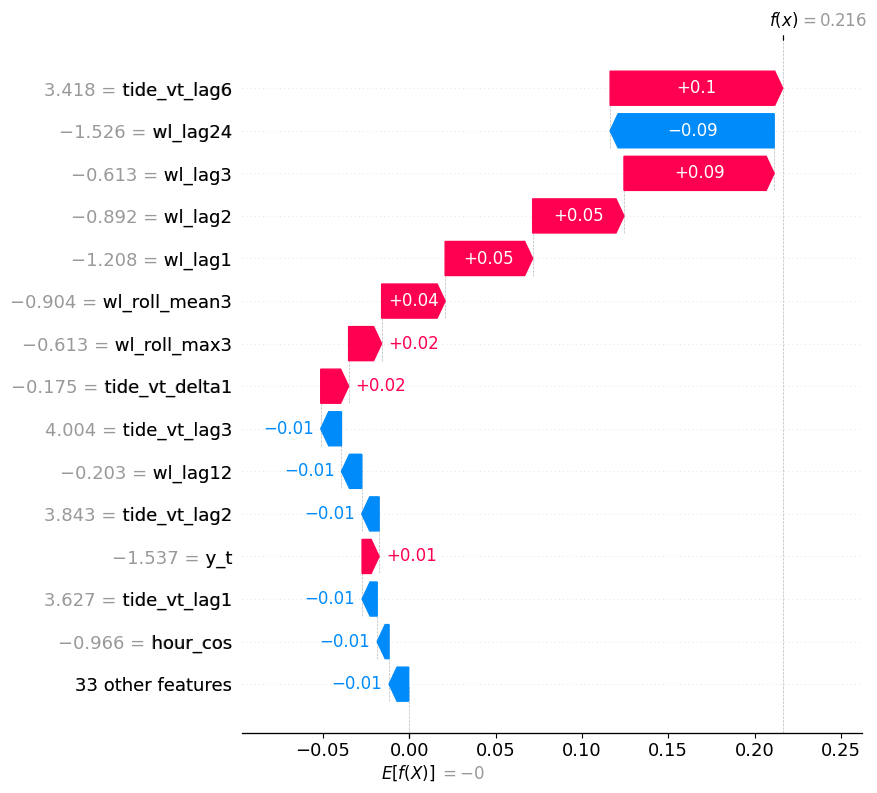

In [66]:

# Explain the same worst-error example
local_explanation = shap.Explanation(
    values=shap_values_h1[worst_pos],
    base_values=explainer_h1.expected_value,
    data=x_worst.iloc[0].values,
    feature_names=FEAT,
)

shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=True,
)


### 10.6 Save SHAP artifacts

The notebook saves:

- global mean absolute SHAP values;
- SHAP values for the t+1h test set;
- the corresponding test feature matrix.

These can be used later for a dashboard or an explanation report.


In [67]:

np.save(
    OUT / "cuchi_shap_values_h1_test.npy",
    np.asarray(shap_values_h1),
)

X_test_h1.to_csv(
    OUT / "cuchi_shap_features_h1_test.csv",
    index=False,
)

# Store a compact summary for downstream use
shap_summary = {
    "model": "LightGBM",
    "horizon_h": 1,
    "explanation_target": "predicted_delta_water_level",
    "test_rows": int(len(X_test_h1)),
    "top_features": mean_abs_shap.head(20).index.tolist(),
}

with open(
    OUT / "cuchi_shap_metadata_h1.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(shap_summary, f, ensure_ascii=False, indent=2)

print("Saved SHAP artifacts to:", OUT)


Saved SHAP artifacts to: /kaggle/working


In [68]:

imp = (
    pd.Series(models[1].feature_importances_, index=FEAT)
    .sort_values(ascending=False)
)

print(imp.head(20).to_string())
imp.head(20).to_csv(OUT / "cuchi_feature_importance_h1.csv")


tide_vt_lag6                  407
tide_vt_delta1                322
wl_lag24                      201
y_t                           197
wl_lag1                       190
wl_lag12                      176
wl_lag6                       176
wl_roll_max12                 156
wl_lag3                       144
Tram_Cu_Chi_pressure_msl      133
wl_lag2                       101
wl_roll_mean12                100
tide_vt_lag2                   97
tide_vt_lag3                   95
tide_vt_lag1                   94
tide_vungtau_m                 91
wl_roll_mean6                  76
hour_cos                       73
wl_roll_max3                   64
Tram_Cu_Chi_wind_speed_10m     63


## 11. Flood severity from predicted water level

### Important: the `Cu-Chi-post.csv` water level is normalized

The published dataset states that post-processed water levels were **homogenized for reference-point differences and normalized across sensors**. The normalization subtracts the mean water level of each sensor, so these values are not directly on the same absolute elevation datum as published flood marks such as 1.5 m or 2.3 m.

Therefore, the absolute thresholds discussed earlier **must not be applied directly** to this CSV.

For this notebook we use a clearly labeled **Củ Chi normalized-scale severity scheme**, calibrated to the observed/event structure of this series:

| Status | Normalized water level | Interpretation |
|---:|---:|---|
| 0 | `< 0.50 m` | Normal |
| 1 | `0.50 – <0.70 m` | Elevated / early warning |
| 2 | `0.70 – <0.90 m` | High / significant flood risk |
| 3 | `≥ 0.90 m` | Extreme / severe event |

These cutoffs are **proposed operational thresholds on the normalized series**, not official hydrological warning marks. They are chosen because the 2022 Củ Chi series has its 90th percentile near 0.70 m and 95th percentile near 0.83 m, while documented high-water/flood periods in late Sep, mid-Oct, late Oct, late Nov and early Dec occupy progressively elevated ranges. The threshold block is intentionally configurable so it can be replaced once an absolute Củ Chi datum/official threshold becomes available.

### Evaluation protocol

For each horizon:

1. `true_status` is derived from the **observed future water level**.
2. `pred_status` is derived from the **predicted future water level**.
3. We compare the four severity classes using:
   - Precision
   - Recall
   - F1
   - F-beta (`β = 0.5` and `β = 2`)
   - Macro and weighted averages
   - Confusion matrix

`F2` gives more weight to recall, which is useful for an alerting system where missing a severe event is more costly than issuing an extra warning.


In [69]:

# ------------------------------------------------------------
# Configurable normalized-scale flood severity thresholds
# ------------------------------------------------------------
# NOTE:
# These are NOT official absolute flood-warning marks.
# They are applied to the normalized Cu-Chi-post water-level scale.
SEVERITY_THRESHOLDS = {
    1: 0.50,  # status 1 starts at 0.50 m
    2: 0.70,  # status 2 starts at 0.70 m
    3: 0.90,  # status 3 starts at 0.90 m
}

SEVERITY_LABELS = {
    0: "Normal",
    1: "Elevated",
    2: "High",
    3: "Extreme",
}

FBETA_VALUES = [0.5, 2.0]


def water_level_to_severity(level):
    if pd.isna(level):
        return np.nan
    if level < SEVERITY_THRESHOLDS[1]:
        return 0
    if level < SEVERITY_THRESHOLDS[2]:
        return 1
    if level < SEVERITY_THRESHOLDS[3]:
        return 2
    return 3


def severity_confusion_metrics(y_true, y_pred):
    """Return one-vs-rest metrics for severity classes 0/1/2/3."""
    rows = []

    for cls in [0, 1, 2, 3]:
        y_true_bin = (np.asarray(y_true) == cls).astype(int)
        y_pred_bin = (np.asarray(y_pred) == cls).astype(int)

        row = {
            "class": cls,
            "severity": SEVERITY_LABELS[cls],
            "support": int(y_true_bin.sum()),
            "precision": precision_score(
                y_true_bin, y_pred_bin, zero_division=0
            ),
            "recall": recall_score(
                y_true_bin, y_pred_bin, zero_division=0
            ),
            "f1": f1_score(
                y_true_bin, y_pred_bin, zero_division=0
            ),
        }

        for beta in FBETA_VALUES:
            row[f"f{beta:g}"] = fbeta_score(
                y_true_bin,
                y_pred_bin,
                beta=beta,
                zero_division=0,
            )

        rows.append(row)

    return pd.DataFrame(rows)


severity_results = {}
severity_metric_rows = []
severity_summary_rows = []

for h in HORIZONS:
    data = df.dropna(subset=[f"target_h{h}"]).copy().reset_index(drop=True)

    n = len(data)
    i_tr = int(n * 0.70)
    i_va = int(n * 0.85)
    te = data.iloc[i_va:].copy()

    pred = preds_test[h].copy()

    # True severity from observed future level
    pred["true_status"] = pred[f"target_h{h}"].apply(
        water_level_to_severity
    ).astype(int)

    # Predicted severity from predicted future level
    pred["pred_status"] = pred["pred_level"].apply(
        water_level_to_severity
    ).astype(int)

    y_true_status = pred["true_status"].to_numpy()
    y_pred_status = pred["pred_status"].to_numpy()

    # Per-class one-vs-rest metrics
    per_class = severity_confusion_metrics(
        y_true_status,
        y_pred_status,
    )
    per_class["horizon_h"] = h
    severity_metric_rows.append(per_class)

    # Multi-class aggregate metrics
    exact_accuracy = float(
        np.mean(y_true_status == y_pred_status)
    )

    macro_precision = precision_score(
        y_true_status,
        y_pred_status,
        labels=[0, 1, 2, 3],
        average="macro",
        zero_division=0,
    )
    macro_recall = recall_score(
        y_true_status,
        y_pred_status,
        labels=[0, 1, 2, 3],
        average="macro",
        zero_division=0,
    )
    macro_f1 = f1_score(
        y_true_status,
        y_pred_status,
        labels=[0, 1, 2, 3],
        average="macro",
        zero_division=0,
    )
    weighted_f1 = f1_score(
        y_true_status,
        y_pred_status,
        labels=[0, 1, 2, 3],
        average="weighted",
        zero_division=0,
    )

    macro_fbeta = {}
    weighted_fbeta = {}

    for beta in FBETA_VALUES:
        macro_fbeta[beta] = fbeta_score(
            y_true_status,
            y_pred_status,
            beta=beta,
            labels=[0, 1, 2, 3],
            average="macro",
            zero_division=0,
        )
        weighted_fbeta[beta] = fbeta_score(
            y_true_status,
            y_pred_status,
            beta=beta,
            labels=[0, 1, 2, 3],
            average="weighted",
            zero_division=0,
        )

    severity_summary_rows.append({
        "horizon_h": h,
        "accuracy_exact": exact_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_f0.5": macro_fbeta[0.5],
        "macro_f2": macro_fbeta[2.0],
        "weighted_f0.5": weighted_fbeta[0.5],
        "weighted_f2": weighted_fbeta[2.0],
        "test_n": len(pred),
    })

    severity_results[h] = pred

    pred.to_csv(
        OUT / f"cuchi_flood_severity_h{h}h_test.csv",
        index=False,
    )

    print("\n" + "=" * 70)
    print(f"Flood severity evaluation — t+{h}h")
    print("=" * 70)
    print("Thresholds:", SEVERITY_THRESHOLDS)
    print("\nTrue class counts:")
    print(pred["true_status"].value_counts().sort_index())
    print("\nPredicted class counts:")
    print(pred["pred_status"].value_counts().sort_index())

    print("\nPer-class metrics:")
    print(
        per_class[
            [
                "class",
                "severity",
                "support",
                "precision",
                "recall",
                "f1",
                "f0.5",
                "f2",
            ]
        ].to_string(index=False)
    )

    print("\nAggregate metrics:")
    print(pd.Series(severity_summary_rows[-1]).to_string())

    print("\nConfusion matrix (rows=true, columns=pred):")
    print(
        confusion_matrix(
            y_true_status,
            y_pred_status,
            labels=[0, 1, 2, 3],
        )
    )

severity_per_class_df = pd.concat(
    severity_metric_rows,
    ignore_index=True,
)

severity_summary_df = pd.DataFrame(
    severity_summary_rows
)

severity_per_class_df.to_csv(
    OUT / "cuchi_flood_severity_per_class_metrics.csv",
    index=False,
)

severity_summary_df.to_csv(
    OUT / "cuchi_flood_severity_summary_metrics.csv",
    index=False,
)

print("\n=== FLOOD SEVERITY SUMMARY ===")
print(severity_summary_df.to_string(index=False))

print("\n=== PER-CLASS SUMMARY ===")
print(severity_per_class_df.to_string(index=False))



Flood severity evaluation — t+1h
Thresholds: {1: 0.5, 2: 0.7, 3: 0.9}

True class counts:
true_status
0    297
1     22
Name: count, dtype: int64

Predicted class counts:
pred_status
0    298
1     21
Name: count, dtype: int64

Per-class metrics:
 class severity  support  precision   recall       f1     f0.5       f2
     0   Normal      297   0.996644 1.000000 0.998319 0.997314 0.999327
     1 Elevated       22   1.000000 0.954545 0.976744 0.990566 0.963303
     2     High        0   0.000000 0.000000 0.000000 0.000000 0.000000
     3  Extreme        0   0.000000 0.000000 0.000000 0.000000 0.000000

Aggregate metrics:
horizon_h            1.000000
accuracy_exact       0.996865
macro_precision      0.499161
macro_recall         0.488636
macro_f1             0.493766
weighted_f1          0.996831
macro_f0.5           0.496970
macro_f2             0.490657
weighted_f0.5        0.996848
weighted_f2          0.996843
test_n             319.000000

Confusion matrix (rows=true, columns=pred

## 12. Interpretation of flood-severity results

The flood-warning task is evaluated as a **four-class severity classification problem** derived from continuous water-level forecasts:

`predicted water level → severity threshold mapping → predicted severity 0/1/2/3`

Likewise:

`observed future water level → severity threshold mapping → true severity 0/1/2/3`

### Metrics

- **Precision:** among predictions of a severity level, how many were correct.
- **Recall:** among actual observations of that severity level, how many were detected.
- **F1:** harmonic mean of precision and recall.
- **F0.5:** weights precision more than recall.
- **F2:** weights recall more than precision and is useful when missing a severe event is more costly.
- **Macro average:** treats all four severity levels equally.
- **Weighted average:** accounts for class frequency.
- **Confusion matrix:** rows = true severity; columns = predicted severity.

### Important limitation

These labels are **threshold-derived labels**, not independent flood observations. The regression model remains the primary predictive model; the severity classifier is a deterministic post-processing layer.

The thresholds are currently on the **normalized Củ Chi dataset scale**. They should be replaced by absolute, station-specific official thresholds only after a compatible vertical datum/reference is available.


## 13. Optional plots

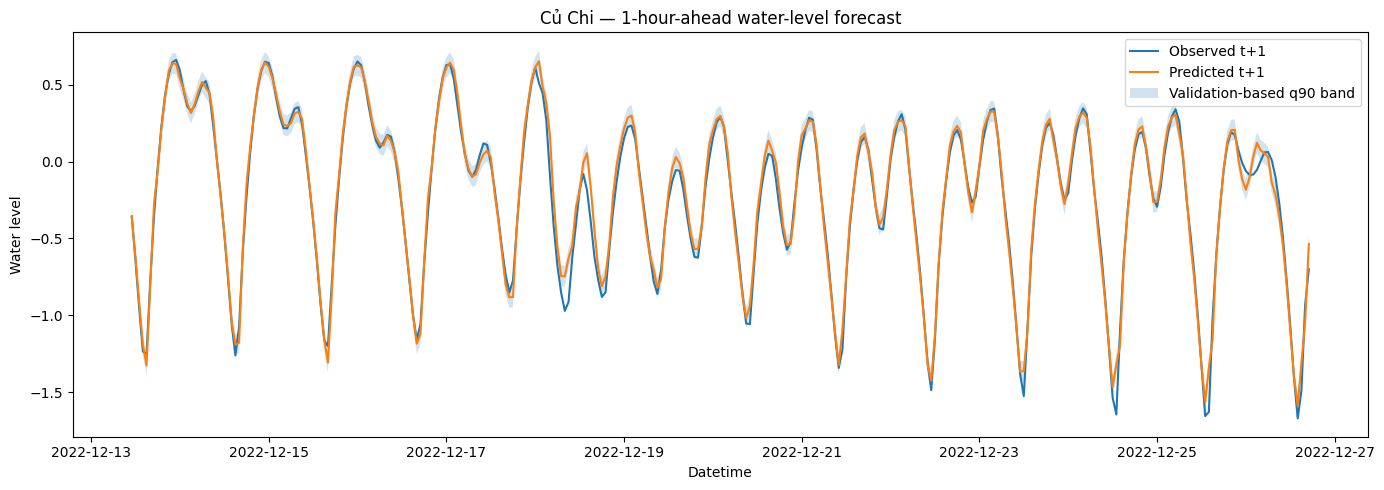

In [70]:

import matplotlib.pyplot as plt

# Test-period forecast plot for t+1h
te1 = preds_test[1]

plt.figure(figsize=(14, 5))
plt.plot(te1["datetime"], te1["target_h1"], label="Observed t+1")
plt.plot(te1["datetime"], te1["pred_level"], label="Predicted t+1")
plt.fill_between(
    te1["datetime"],
    te1["pred_lo"],
    te1["pred_hi"],
    alpha=0.2,
    label="Validation-based q90 band",
)
plt.xlabel("Datetime")
plt.ylabel("Water level")
plt.title("Củ Chi — 1-hour-ahead water-level forecast")
plt.legend()
plt.tight_layout()
plt.show()


## 14. Export models and metadata

In [71]:
from pathlib import Path
import shutil

DEPLOY_DIR = MODEL_DIR / "deployment"
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

# Models intended for downstream project pipelines.
for h, model in production_models.items():
    joblib.dump(model, DEPLOY_DIR / f"cuchi_lgb_h{h}h_production.joblib")

# Evaluation copies are retained for reproducibility.
for h, model in models.items():
    joblib.dump(model, DEPLOY_DIR / f"cuchi_lgb_h{h}h_eval.joblib")

with open(DEPLOY_DIR / "feature_schema.json", "w", encoding="utf-8") as f:
    json.dump({
        "station": "Củ Chi",
        "features": FEAT,
        "horizons_hours": HORIZONS,
        "target_type": "delta_water_level",
        "reconstruction": "future_level = current_water_level + predicted_delta",
        "rolling_features_are_causal": True,
        "rolling_window_excludes_current_y_t": True,
        "ar_lags_baseline": AR_LAGS,
        "seasonal_period_hours_baseline": SEASONAL_PERIOD_HOURS,
    }, f, ensure_ascii=False, indent=2)

with open(DEPLOY_DIR / "validation_q90.json", "w", encoding="utf-8") as f:
    json.dump({str(h): float(validation_intervals[h]) for h in HORIZONS}, f, indent=2)

static_payload = {
    out_name: float(cuchi_static[src_name])
    for src_name, out_name in STATIC_COL_MAP.items()
}
with open(DEPLOY_DIR / "station_static_features.json", "w", encoding="utf-8") as f:
    json.dump(static_payload, f, ensure_ascii=False, indent=2)

baseline_df.to_csv(DEPLOY_DIR / "baseline_metrics.csv", index=False)
comparison.to_csv(DEPLOY_DIR / "model_comparison.csv", index=False)
improvement_df.to_csv(DEPLOY_DIR / "baseline_improvement.csv", index=False)
metrics_df.to_csv(DEPLOY_DIR / "lightgbm_test_metrics.csv", index=False)

metadata = {
    "station": "Củ Chi",
    "model_version": "cuchi_hourly_baselines_v2",
    "data_period": f"{df['datetime'].min()} -> {df['datetime'].max()}",
    "horizons_hours": HORIZONS,
    "target": "delta water level; future_level = current_level + predicted_delta",
    "production_models": {str(h): f"cuchi_lgb_h{h}h_production.joblib" for h in HORIZONS},
    "evaluation_models": {str(h): f"cuchi_lgb_h{h}h_eval.joblib" for h in HORIZONS},
    "split": "70% chronological train / 15% validation / 15% test",
    "production_fit": "train + validation (85%), using best_iteration selected on validation",
    "baselines": ["Persistence", "SeasonalNaive24", f"AutoReg{AR_LAGS} expanding-window"],
}
with open(DEPLOY_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# Small loader/predictor helper for the next pipeline.
inference_code = """from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

class CuchiHourlyPredictor:
    def __init__(self, model_dir):
        self.model_dir = Path(model_dir)
        with open(self.model_dir / 'feature_schema.json', 'r', encoding='utf-8') as f:
            self.schema = json.load(f)
        self.features = self.schema['features']
        self.horizons = [int(h) for h in self.schema['horizons_hours']]
        self.models = {h: joblib.load(self.model_dir / f'cuchi_lgb_h{h}h_production.joblib') for h in self.horizons}

    def predict_from_features(self, feature_row, current_water_level, horizon):
        horizon = int(horizon)
        if horizon not in self.models:
            raise ValueError(f'Unsupported horizon: {horizon}; available={self.horizons}')
        X = pd.DataFrame([feature_row]) if isinstance(feature_row, dict) else feature_row.copy()
        missing = [c for c in self.features if c not in X.columns]
        if missing:
            raise ValueError(f'Missing model features: {missing}')
        X = X[self.features].replace([np.inf, -np.inf], np.nan).fillna(0)
        delta = float(self.models[horizon].predict(X)[0])
        return {
            'horizon_h': horizon,
            'current_water_level': float(current_water_level),
            'predicted_delta': delta,
            'predicted_water_level': float(current_water_level) + delta,
        }

"""
(DEPLOY_DIR / "cuchi_inference.py").write_text(inference_code, encoding="utf-8")

zip_base = OUT / "cuchi_hourly_model_bundle"
zip_path = Path(shutil.make_archive(str(zip_base), "zip", root_dir=DEPLOY_DIR))

print("Deployment folder:", DEPLOY_DIR)
print("ZIP bundle:", zip_path)
for p in sorted(DEPLOY_DIR.iterdir()):
    print(" -", p.name)


Deployment folder: /kaggle/working/cuchi_hourly_revised/deployment
ZIP bundle: /kaggle/working/cuchi_hourly_model_bundle.zip
 - baseline_improvement.csv
 - baseline_metrics.csv
 - cuchi_inference.py
 - cuchi_lgb_h1h_eval.joblib
 - cuchi_lgb_h1h_production.joblib
 - cuchi_lgb_h24h_eval.joblib
 - cuchi_lgb_h24h_production.joblib
 - cuchi_lgb_h3h_eval.joblib
 - cuchi_lgb_h3h_production.joblib
 - cuchi_lgb_h6h_eval.joblib
 - cuchi_lgb_h6h_production.joblib
 - feature_schema.json
 - lightgbm_test_metrics.csv
 - metadata.json
 - model_comparison.csv
 - station_static_features.json
 - validation_q90.json


## 14.1 Static-feature result and interpretation

### What changed?

The notebook now carries station metadata explicitly. For the attached `stations_master_features.csv`, the Củ Chi row contains the station-level static attributes used by this notebook.

### What should we expect from the current model?

For a **single-station Củ Chi time series**, adding Củ Chi's static values does not add temporal information. The same number is repeated for every Củ Chi timestamp.

Therefore:

- it should not materially improve RMSE / MAE / R²;
- it should not create a meaningful LightGBM split;
- it should contribute little or nothing to SHAP;
- its main value is contextual metadata and preparation for a multi-station model.

### What model would actually benefit from static station features?

Use one training table containing multiple stations:

`station × datetime → water level`

Then:

`static station features + dynamic weather/tide + lagged water level → future water level`

Now the static features vary across stations and can explain differences in baseline behavior and sensitivity.

This is the scientifically meaningful way to test whether variables such as river distance, tide influence, impervious area, or channel density improve generalization across stations.


## 15. Final checklist

### Forecasting
- [x] Chronological split
- [x] Persistence baseline
- [x] Seasonal Naive (24 h) baseline
- [x] Expanding-window AutoReg(24) baseline
- [x] LightGBM t+1 / t+3 / t+6
- [x] RMSE / MAE / R²
- [x] Comparison against all baselines
- [x] Feature importance
- [x] Validation-based uncertainty band

### Deployment
- [x] Production models retrained on train + validation
- [x] Best iteration selected using validation only
- [x] Feature schema exported
- [x] Static station metadata exported
- [x] Inference helper exported
- [x] Deployment ZIP bundle exported

### Leakage control
- [x] No future targets in feature matrix
- [x] Lag features use past values
- [x] Rolling features exclude the current target timestamp
- [x] Test period is not used for fitting evaluation models
- [x] Production retraining uses only train + validation
- [x] AutoReg uses only information available at each forecast origin
